In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplot inline

UsageError: Line magic function `%matplot` not found.


In [4]:
df=pd.read_csv('economic_index.csv')

In [5]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [8]:
df.drop(columns=['year', 'month'], axis=1, inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [9]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

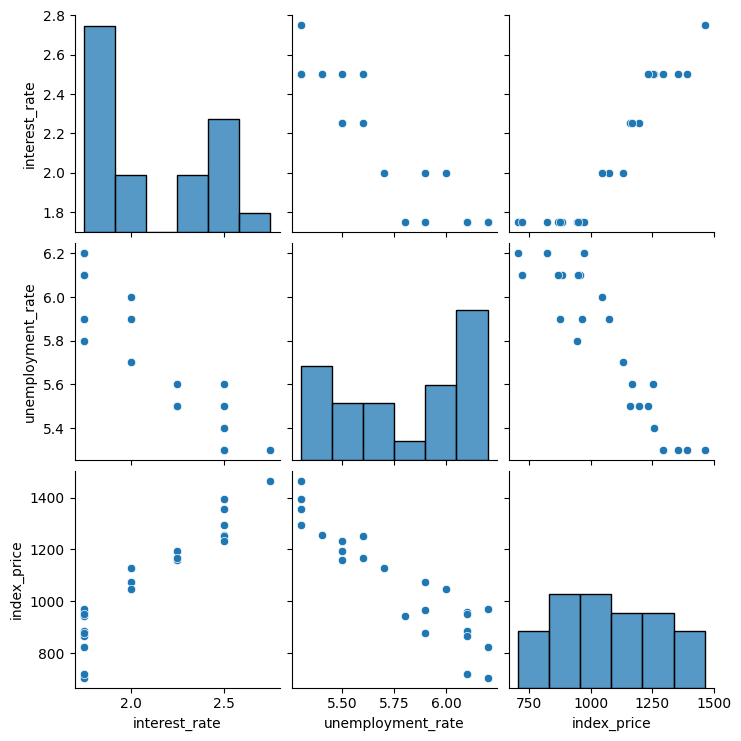

In [10]:
#visulizations
import seaborn as sns
sns.pairplot(df)

In [11]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

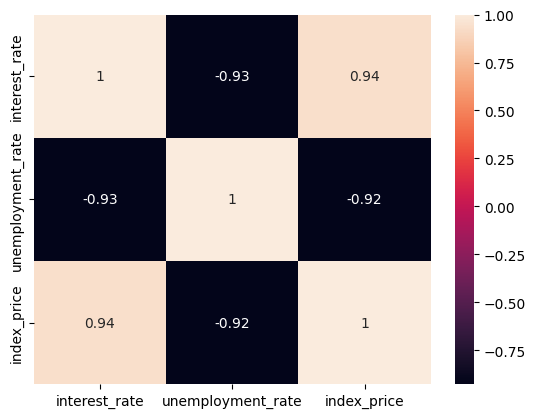

In [12]:
sns.heatmap(df.corr(), annot=True, cmap='rocket')

Text(0, 0.5, 'unemployment_rate')

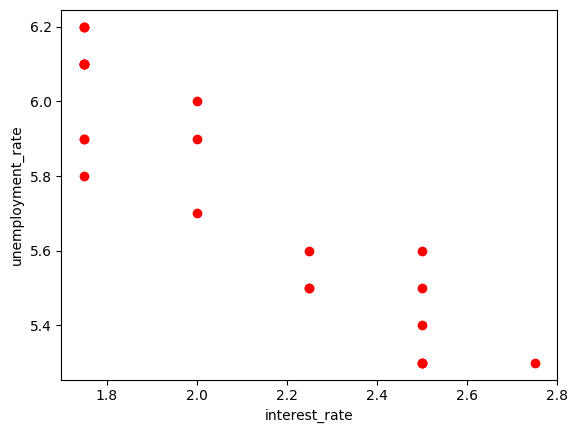

In [14]:
plt.scatter(df['interest_rate'], df['unemployment_rate'], color='red')
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")

In [15]:
#independent and dependent features
x=df.iloc[:,:-1]
y=df['index_price']

In [16]:
#train_test_split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

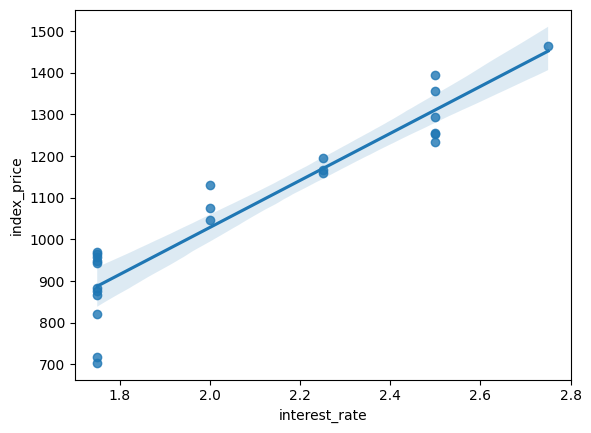

In [17]:
#reg plot
sns.regplot(x='interest_rate', y='index_price', data=df)


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

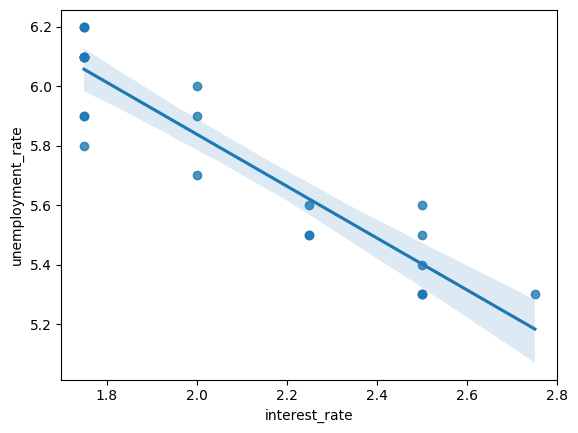

In [18]:
#reg plot
sns.regplot(x='interest_rate', y='unemployment_rate', data=df)


In [19]:
#stndard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
#machine learning model
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
#cross validation score
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(model, x_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5 )

In [24]:
validation_score

array([-1606.47408206, -9579.95329208, -7961.60935985, -8392.32547433,
        -773.2668524 ])

In [23]:
np.mean(validation_score)

np.float64(-5662.72581214445)

In [26]:
#prediction
y_pred=model.predict(x_test_scaled)

In [27]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [29]:
#performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 6957.105303258833
Mean Absolute Error: 71.71878409976625
R-squared: 0.8254940547158576
Root Mean Squared Error: 83.40926389351985


## assumptions

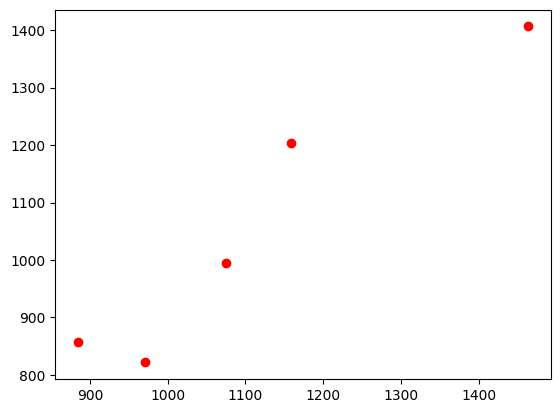

In [31]:
plt.scatter(y_test, y_pred, color='red')

In [32]:
residuals=y_test-y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


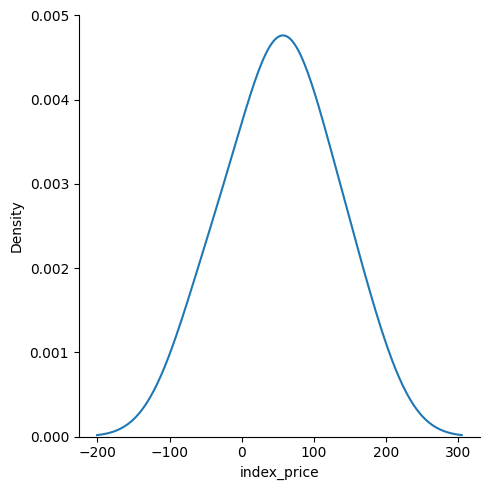

In [33]:
##plotting the residuals
sns.displot(residuals, kind='kde')

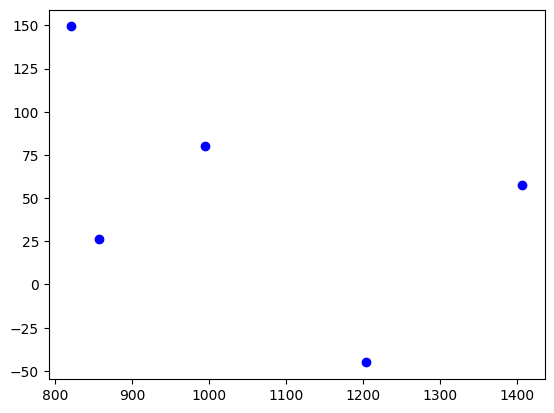

In [34]:
#scatter plot wrt prediction and residuals
plt.scatter(y_pred, residuals, color='blue')

In [37]:
#ols linear regression
import statsmodels.api as sm
model=sm.OLS(y_train, x_train_scaled).fit()

In [38]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                       0.751
Time:                        19:22:41   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""